# Module Nine Project

For the module nine project you are required to produce coding samples in accordance with the requirements in the project guidelines and rubric. This Notebook has been pre-created as a shell for your project submission.

Once your code is complete, you will download this notebook as an HTML file by clicking **File**, then **Download As**, then **HTML (.html)** from the Jupyter menu bar. Validate that your code and outputs are rendered in the html file before submission.

<div class="alert alert-block alert-danger">
    <span style="color:black"><b><i>Missing Blocks:</i></b> Ensure that you have clicked <b><mark>Run</mark></b> for all blocks before downloading as an HTML file or the block may be missing from your submission.</span>
</div>

### Data Source Information
Below are some example reputable data sources that you can use to collect your minimum of two data sets from:

- https://datasetsearch.research.google.com/
- https://www.kaggle.com/datasets
- https://data.gov/
- https://www.census.gov/data.html
- https://www.bls.gov/data/
- https://databank.worldbank.org/databases
- https://www.ncei.noaa.gov/access/search/index
- https://www.epa.gov/data
- https://www.pewresearch.org/tools-and-datasets/
- https://www.who.int/data/
- https://dataverse.harvard.edu/
- https://search.cdc.gov/search/?query=dataset&dpage=1
- https://data.fivethirtyeight.com/
- https://www.gdeltproject.org/data.html
- https://datahub.io/collections


***Note: this list is not all inclusive, if you have a reputable data set that you have collected, or would like to use, please ensure to upload the data. All data sets will need to be documented in your submission as to the source through the creation of a citation.***

<div class="alert alert-block alert-success">
    <span style="color:black"><b><i>To Begin:</i></b> replace each <b>data_file_#</b> entry sample data path with the path to your selected data sets.</span>
</div>

You are welcome to use more than two data sets, create an entry for each as applicable for each data set. Ensure that you create comments that provide citations for the data sets you have selected for use. When working through your submission, keep in mind that you will need to have choosen two separate groups of stakeholders to create your final visualizations.

In [9]:
# Set file paths and source citations.
from pathlib import Path

# Data citation information (exactly two datasets)
dataSources = {
    "Education2023.csv": "USDA Economic Research Service (ERS), County-level Data Sets, Educational attainment",
    "Unemployment2023.csv": "USDA Economic Research Service (ERS), County-level Data Sets, Unemployment",
    "sourceUrl": "https://www.ers.usda.gov/data-products/county-level-data-sets/",
}

baseDir = Path("data/sample_use_only")
dataFile1 = baseDir / "Education2023.csv"
dataFile2 = baseDir / "Unemployment2023.csv"

print("Data source citations:")
for name, citation in dataSources.items():
    if name != "sourceUrl":
        print(f"- {name}: {citation}")
print(f"- Reference page: {dataSources['sourceUrl']}")

print("\nDataset paths:")
for filePath in [dataFile1, dataFile2]:
    print(f"- {filePath} | exists={filePath.exists()}")

Data source citations:
- Education2023.csv: USDA Economic Research Service (ERS), County-level Data Sets, Educational attainment
- Unemployment2023.csv: USDA Economic Research Service (ERS), County-level Data Sets, Unemployment
- Reference page: https://www.ers.usda.gov/data-products/county-level-data-sets/

Dataset paths:
- data/sample_use_only/Education2023.csv | exists=True
- data/sample_use_only/Unemployment2023.csv | exists=True


## Installing Required Packages
If you have additional packages that you would like to use or install, add them to the **requirements.txt** file then run the next two blocks.

In [ ]:
# Update pip to the latest version.
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.0 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.1.1
    Uninstalling pip-26.1.1:
      Successfully uninstalled pip-26.1.1


In [ ]:
# Install packages from requirements.txt.
!pip install -r requirements.txt

## Import the Required Packages

In [10]:
# Import libraries and set display/plot defaults.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", context="talk")

## Loading the Data
Create entries to load your data for your submission.

In [11]:
# Load both datasets and preview sample rows.
educationRaw = pd.read_csv(dataFile1)
unemploymentRaw = pd.read_csv(dataFile2)

# Standardize key column names to simplify downstream blending
educationRaw = educationRaw.rename(columns={"FIPS Code": "FIPS_Code", "Area name": "Area_Name"})

dataSets = {
    "education": educationRaw,
    "unemployment": unemploymentRaw,
}

for name, df in dataSets.items():
    print(f"{name.title()} shape: {df.shape}")
    display(df.head(3))

Education shape: (432, 5)


,FIPS_Code,State,Area_Name,Attribute,Value
0,0,US,United States,"Less than high school graduate, 2019-23",24230217.00
1,0,US,United States,"High school graduate (or equivalency), 2019-23",59836489.00
2,0,US,United States,"Some college or associate degree, 2019-23",64413653.00


Unemployment shape: (1184, 5)


,FIPS_Code,State,Area_Name,Attribute,Value
0,0,US,United States,Civilian_labor_force_2019,163815894.00
1,0,US,United States,Employed_2019,157805901.00
2,0,US,United States,Unemployed_2019,6009993.00


## Examining the Data
Create entries to conduct exploratory data analysis to identify key data points to include relevant data from your two data sets while evaluating the quality of your choosen data.

In [18]:
# Profile each dataset for quality and structure checks.
def qualitySnapshot(df, name):
    # Print a quick dataset size summary.
    print(f"\n===== {name.upper()} DATA QUALITY SNAPSHOT =====")
    print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
    # Show missing values per column.
    print("Missing values by column:")
    display(df.isna().sum().to_frame("missingCount"))

    # Count duplicate key rows for FIPS + Attribute pairs.
    if {"FIPS_Code", "Attribute"}.issubset(df.columns):
        dupes = df.duplicated(subset=["FIPS_Code", "Attribute"]).sum()
        print(f"Duplicate [FIPS_Code, Attribute] rows: {dupes:,}")

    # Preview attribute categories available in the file.
    print("Example unique attributes:")
    display(pd.Series(df["Attribute"].dropna().unique()).head(10))

# Run the same quality checks for both datasets.
for name, df in dataSets.items():
    qualitySnapshot(df, name)

# Convert analysis fields to numeric so calculations are reliable.
for df in dataSets.values():
    df["FIPS_Code"] = pd.to_numeric(df["FIPS_Code"], errors="coerce")
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# Remove national aggregate rows and keep state-level records only.
education = educationRaw.loc[educationRaw["FIPS_Code"] > 0].copy()
unemployment = unemploymentRaw.loc[unemploymentRaw["FIPS_Code"] > 0].copy()

# Confirm filtered row counts for each dataset.
print("\nFiltered row counts after removing US aggregate rows (FIPS_Code == 0):")
print(f"Education: {len(education):,}")
print(f"Unemployment: {len(unemployment):,}")

# Find attribute names by keyword so the code adapts to source labels.
def findAttribute(options, containsText):
    for item in options:
        if containsText.lower() in str(item).lower():
            return item
    raise ValueError(f"Could not find attribute containing: {containsText}")

# Select the exact attributes used for downstream analysis.
eduBachelorsAttr = findAttribute(education["Attribute"].dropna().unique(), "Percent of adults with a bachelor's degree or higher")
unempRateAttr = findAttribute(unemployment["Attribute"].dropna().unique(), "Unemployment_rate_2023")
laborForceAttr = findAttribute(unemployment["Attribute"].dropna().unique(), "Civilian_labor_force_2023")
medianIncomeAttr = findAttribute(unemployment["Attribute"].dropna().unique(), "Median_Household_Income_2022")

# Print chosen attributes for traceability.
print("\nSelected attributes for integrated analysis:")
print(f"- Education: {eduBachelorsAttr}")
print(f"- Unemployment: {unempRateAttr}")
print(f"- Labor force: {laborForceAttr}")
print(f"- Income: {medianIncomeAttr}")


===== EDUCATION DATA QUALITY SNAPSHOT =====
Rows: 432 | Columns: 5
Missing values by column:


,missingCount
FIPS_Code,0
State,0
Area_Name,0
Attribute,0
Value,0


Duplicate [FIPS_Code, Attribute] rows: 0
Example unique attributes:


0              Less than high school graduate, 2019-23
1       High school graduate (or equivalency), 2019-23
2            Some college or associate degree, 2019-23
3                 Bachelor's degree or higher, 2019-23
4    Percent of adults who are not high school grad...
5    Percent of adults who are high school graduate...
6    Percent of adults completing some college or a...
7    Percent of adults with a bachelor's degree or ...
dtype: object


===== UNEMPLOYMENT DATA QUALITY SNAPSHOT =====
Rows: 1,184 | Columns: 5
Missing values by column:


,missingCount
FIPS_Code,0
State,0
Area_Name,0
Attribute,0
Value,0


Duplicate [FIPS_Code, Attribute] rows: 0
Example unique attributes:


0    Civilian_labor_force_2019
1                Employed_2019
2              Unemployed_2019
3       Unemployment_rate_2019
4    Civilian_labor_force_2020
5                Employed_2020
6              Unemployed_2020
7       Unemployment_rate_2020
8    Civilian_labor_force_2021
9                Employed_2021
dtype: object


Filtered row counts after removing US aggregate rows (FIPS_Code == 0):
Education: 424
Unemployment: 1,163

Selected attributes for integrated analysis:
- Education: Percent of adults with a bachelor's degree or higher, 2019-23
- Unemployment: Unemployment_rate_2023
- Labor force: Civilian_labor_force_2023
- Income: Median_Household_Income_2022


## Data Preprocessing Techniques
Create entries to clean and blend your data sets as applicable consolidating the two or more data sets into a single collection for inclusion into your visualizations.

In [19]:
# Build a clean, analysis-ready table by extracting and joining key metrics.
def extractMetric(df, attributeName, metricCol):
    # Keep one metric column and preserve common join keys.
    metric = (
        df.loc[df["Attribute"] == attributeName, ["FIPS_Code", "State", "Area_Name", "Value"]]
        .rename(columns={"Value": metricCol})
        .drop_duplicates(subset=["FIPS_Code"])
)
    return metric

# Extract the selected education and labor-market metrics into separate tables.
eduMetric = extractMetric(education, eduBachelorsAttr, "bachelorsPct")
unempMetric = extractMetric(unemployment, unempRateAttr, "unemploymentRate2023")
laborMetric = extractMetric(unemployment, laborForceAttr, "laborForce2023")
incomeMetric = extractMetric(unemployment, medianIncomeAttr, "medianIncome2022")

# Join all extracted metrics into one integrated dataset by FIPS code.
integratedDf = (
    eduMetric
    .merge(unempMetric[["FIPS_Code", "unemploymentRate2023"]], on="FIPS_Code", how="inner")
    .merge(laborMetric[["FIPS_Code", "laborForce2023"]], on="FIPS_Code", how="inner")
    .merge(incomeMetric[["FIPS_Code", "medianIncome2022"]], on="FIPS_Code", how="inner")
)

# Derive estimated unemployed count from labor force and unemployment rate.
integratedDf["estimatedUnemployed2023"] = (
    integratedDf["laborForce2023"] * (integratedDf["unemploymentRate2023"] / 100)
).round(0)

# Remove rows with invalid labor force or impossible education percentages.
integratedDf = integratedDf.loc[
    (integratedDf["laborForce2023"] > 0)
    & (integratedDf["bachelorsPct"].between(0, 100))
]

# Format FIPS codes to 5 digits for consistency.
integratedDf["FIPS_Code"] = integratedDf["FIPS_Code"].astype(int).astype(str).str.zfill(5)

# Keep one representative row per state using the largest labor force record.
integratedStateDf = (
    integratedDf.sort_values("laborForce2023", ascending=False)
    .drop_duplicates(subset=["State"], keep="first")
    .reset_index(drop=True)
)

# Report final dataset size after preprocessing.
print("Integrated blended dataset shape:", integratedStateDf.shape)

# Check for any missing values before visualization.
print("\nMissing values in integrated dataset:")
display(integratedStateDf.isna().sum().to_frame("missingCount"))

# Preview the final preprocessed dataset.
print("\nIntegrated data preview:")
display(integratedStateDf.head())

Integrated blended dataset shape: (51, 8)

Missing values in integrated dataset:


,missingCount
FIPS_Code,0
State,0
Area_Name,0
bachelorsPct,0
unemploymentRate2023,0
laborForce2023,0
medianIncome2022,0
estimatedUnemployed2023,0



Integrated data preview:


,FIPS_Code,State,Area_Name,bachelorsPct,unemploymentRate2023,laborForce2023,medianIncome2022,estimatedUnemployed2023
0,06000,CA,California,36.50,4.80,19308287.00,91517.00,926798.00
1,48000,TX,Texas,33.08,3.90,15067153.00,72279.00,587619.00
2,12000,FL,Florida,33.21,2.90,10988566.00,69287.00,318668.00
3,36000,NY,New York,39.55,4.20,9717791.00,79463.00,408147.00
4,42000,PA,Pennsylvania,34.49,3.40,6518343.00,71789.00,221624.00


## Data Visualizations
Create entries to visualize your data using appropriate visualization types to reveal key trends within the data collection. Integrate multiple data attributes into visualizations using appropriate techniques to derive key insights from your visualizations. In your data visualizations, you will use multi-level data modeling practices to refine your visualizations. Your visualizations should include a high-level visualization that provides a broad overview of the data for one of your two stakeholders, as well as a detailed, insight-focused visualization that highlights the key findings for the other of your two stakeholders.

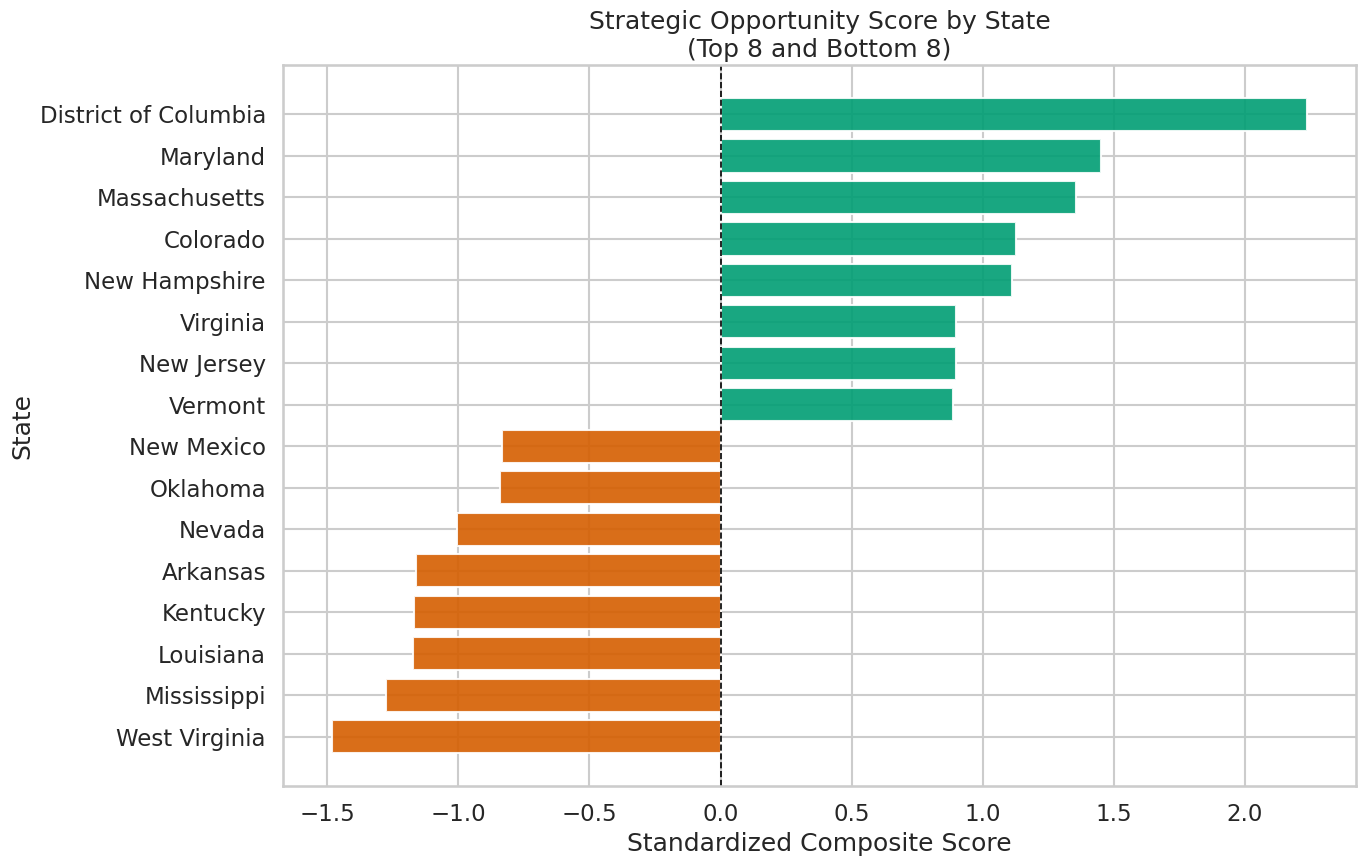

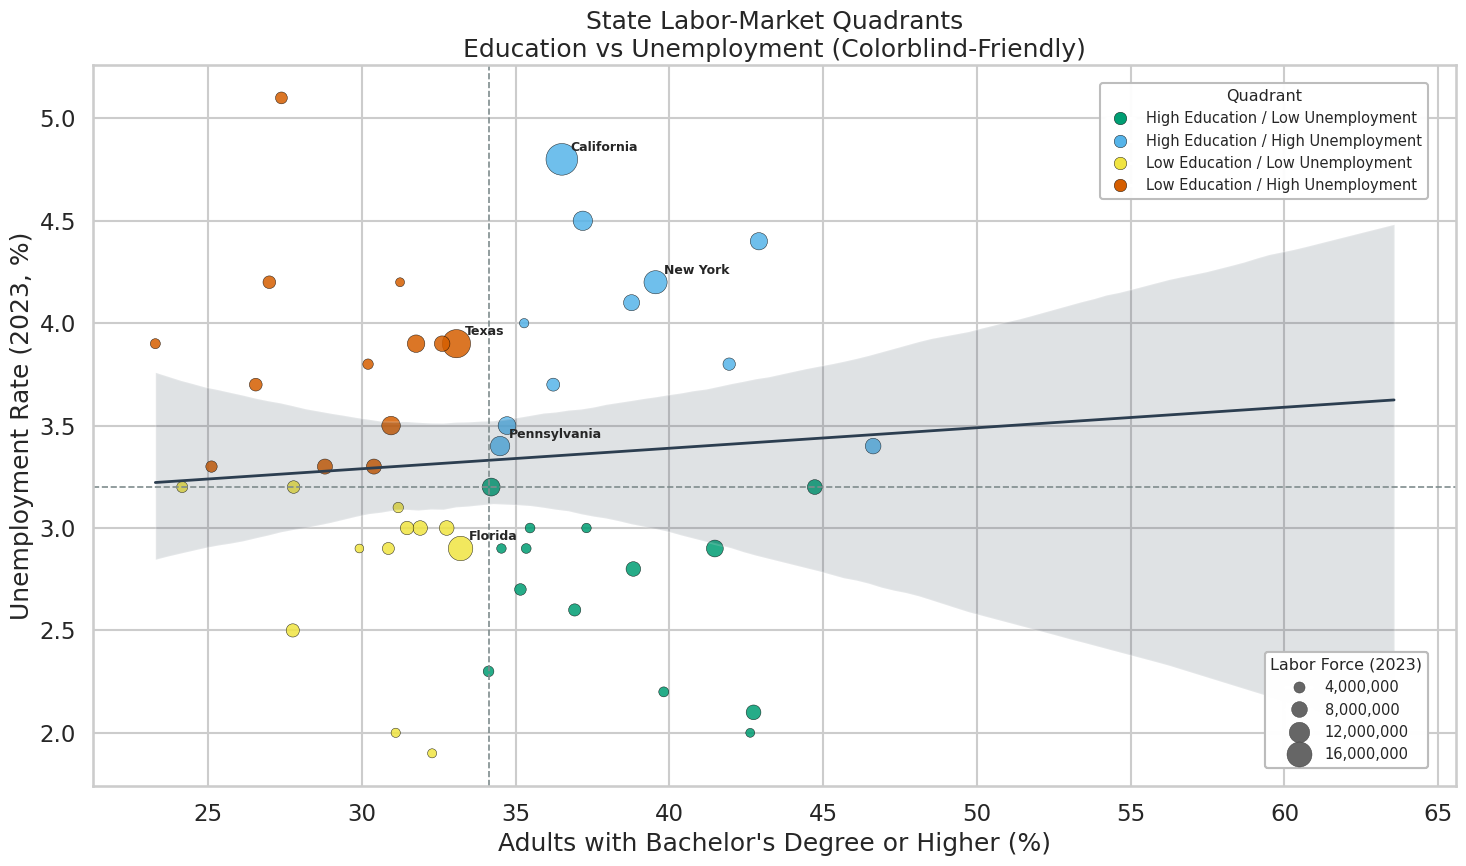

Key Insights:

1) States with strongest overall opportunity scores:


,stateName,opportunityScore,bachelorsPct,unemploymentRate2023,medianIncome2022
47,District of Columbia,2.24,63.56,4.90,99897.00
18,Maryland,1.45,42.74,2.10,94957.00
13,Massachusetts,1.36,46.62,3.40,94538.00
17,Colorado,1.13,44.73,3.20,89096.00
39,New Hampshire,1.11,39.82,2.20,90750.00



2) States with weakest overall opportunity scores:


,stateName,opportunityScore,bachelorsPct,unemploymentRate2023,medianIncome2022
38,West Virginia,-1.48,23.29,3.90,54097.00
34,Mississippi,-1.28,24.16,3.20,52788.00
25,Louisiana,-1.17,26.55,3.70,55458.00
26,Kentucky,-1.17,26.99,4.20,59246.00
33,Arkansas,-1.16,25.11,3.30,55505.00



3) Quadrant diagnostic summary:
- High education + low unemployment states: 14
- Low education + high unemployment states: 13

4) Correlation snapshot including composite score:


,bachelorsPct,unemploymentRate2023,medianIncome2022,opportunityScore
bachelorsPct,1.00,0.09,0.82,0.94
unemploymentRate2023,0.09,1.00,0.13,-0.15
medianIncome2022,0.82,0.13,1.00,0.90
opportunityScore,0.94,-0.15,0.90,1.00



Interpretation:
- The composite score gives a balanced, defensible ranking across education, labor-market conditions, and income.
- The quadrant chart is easier to read because colors now represent clear state groupings.
- The selected palette is colorblind-friendly and improves accessibility for a broader audience.


In [ ]:
# Create stakeholder-focused visuals and summarize the main findings.
stateSummary = integratedStateDf.copy()
stateSummary["stateName"] = stateSummary["Area_Name"]

# Standardize variables so they can be combined into one composite score.
stateSummary["bachelorsZ"] = (stateSummary["bachelorsPct"] - stateSummary["bachelorsPct"].mean()) / stateSummary["bachelorsPct"].std()
stateSummary["unemploymentZ"] = (stateSummary["unemploymentRate2023"] - stateSummary["unemploymentRate2023"].mean()) / stateSummary["unemploymentRate2023"].std()
stateSummary["incomeZ"] = (stateSummary["medianIncome2022"] - stateSummary["medianIncome2022"].mean()) / stateSummary["medianIncome2022"].std()
stateSummary["opportunityScore"] = (0.45 * stateSummary["bachelorsZ"]) + (0.35 * stateSummary["incomeZ"]) - (0.20 * stateSummary["unemploymentZ"])

# Build a ranked view of top and bottom states by opportunity score.
rankView = pd.concat([
    stateSummary.nlargest(8, "opportunityScore"),
    stateSummary.nsmallest(8, "opportunityScore"),
]).sort_values("opportunityScore", ascending=True)

# Plot stakeholder overview chart with clear positive/negative coloring.
plt.figure(figsize=(14, 9))
barColors = ["#D55E00" if score < 0 else "#009E73" for score in rankView["opportunityScore"]]
plt.barh(rankView["stateName"], rankView["opportunityScore"], color=barColors, alpha=0.9)
plt.axvline(0, color="black", linestyle="--", linewidth=1.2)
plt.title("Strategic Opportunity Score by State\n(Top 8 and Bottom 8)")
plt.xlabel("Standardized Composite Score")
plt.ylabel("State")
plt.tight_layout()
plt.show()

# Prepare a simpler, colorblind-friendly diagnostic view for stakeholder interpretation.
detailedView = stateSummary.copy()
xMedian = detailedView["bachelorsPct"].median()
yMedian = detailedView["unemploymentRate2023"].median()

# Assign each state to a readable quadrant label.
detailedView["quadrant"] = np.select(
    [
        (detailedView["bachelorsPct"] >= xMedian) & (detailedView["unemploymentRate2023"] <= yMedian),
        (detailedView["bachelorsPct"] >= xMedian) & (detailedView["unemploymentRate2023"] > yMedian),
        (detailedView["bachelorsPct"] < xMedian) & (detailedView["unemploymentRate2023"] <= yMedian),
        (detailedView["bachelorsPct"] < xMedian) & (detailedView["unemploymentRate2023"] > yMedian),
    ],
    [
        "High Education / Low Unemployment",
        "High Education / High Unemployment",
        "Low Education / Low Unemployment",
        "Low Education / High Unemployment",
    ],
    default="Unclassified",
)

# Use a colorblind-safe palette to improve accessibility.
quadrantPalette = {
    "High Education / Low Unemployment": "#009E73",
    "High Education / High Unemployment": "#56B4E9",
    "Low Education / Low Unemployment": "#F0E442",
    "Low Education / High Unemployment": "#D55E00",
    "Unclassified": "#999999",
}

fig, ax = plt.subplots(figsize=(15, 9))
sns.scatterplot(
    data=detailedView,
    x="bachelorsPct",
    y="unemploymentRate2023",
    hue="quadrant",
    palette=quadrantPalette,
    size="laborForce2023",
    sizes=(40, 520),
    alpha=0.85,
    edgecolor="black",
    linewidth=0.35,
    legend=False,
    ax=ax,
)

# Add trend line and quadrant guides to aid interpretation.
sns.regplot(
    data=detailedView,
    x="bachelorsPct",
    y="unemploymentRate2023",
    scatter=False,
    ci=95,
    color="#2C3E50",
    line_kws={"linewidth": 2},
    ax=ax,
)
ax.axvline(xMedian, color="#7F8C8D", linestyle="--", linewidth=1.2)
ax.axhline(yMedian, color="#7F8C8D", linestyle="--", linewidth=1.2)

# Label only a few major states to keep the chart uncluttered.
for _, row in detailedView.nlargest(5, "laborForce2023").iterrows():
    ax.annotate(
        row["stateName"],
        (row["bachelorsPct"], row["unemploymentRate2023"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

# Create separate, readable legends for color and bubble size.
from matplotlib.lines import Line2D

quadrantOrder = [
    "High Education / Low Unemployment",
    "High Education / High Unemployment",
    "Low Education / Low Unemployment",
    "Low Education / High Unemployment",
]
quadrantHandles = [
    Line2D([0], [0], marker="o", color="w", label=label,
           markerfacecolor=quadrantPalette[label], markeredgecolor="black",
           markeredgewidth=0.3, markersize=9)
    for label in quadrantOrder
]

sizeLevels = [4_000_000, 8_000_000, 12_000_000, 16_000_000]
sizeHandles = [
    Line2D([0], [0], marker="o", color="w", label=f"{val:,}",
           markerfacecolor="#666666", markeredgecolor="#333333",
           markeredgewidth=0.3, markersize=np.interp(val, [4_000_000, 16_000_000], [8, 18]))
    for val in sizeLevels
]

legendQuadrant = ax.legend(
    handles=quadrantHandles,
    title="Quadrant",
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    frameon=True,
    facecolor="white",
    edgecolor="#BBBBBB",
    framealpha=0.96,
    fontsize=10.5,
    title_fontsize=11.5,
)
ax.add_artist(legendQuadrant)

legendSize = ax.legend(
    handles=sizeHandles,
    title="Labor Force (2023)",
    loc="lower right",
    bbox_to_anchor=(0.985, 0.015),
    frameon=True,
    facecolor="white",
    edgecolor="#BBBBBB",
    framealpha=0.96,
    fontsize=10.5,
    title_fontsize=11.5,
)
ax.add_artist(legendSize)

ax.set_title("State Labor-Market Quadrants\nEducation vs Unemployment (Colorblind-Friendly)")
ax.set_xlabel("Adults with Bachelor's Degree or Higher (%)")
ax.set_ylabel("Unemployment Rate (2023, %)")
plt.tight_layout()
plt.show()

# Count quadrant groups to support stakeholder targeting.
highEduLowUnemp = detailedView[detailedView["quadrant"] == "High Education / Low Unemployment"]
lowEduHighUnemp = detailedView[detailedView["quadrant"] == "Low Education / High Unemployment"]

# Print key findings tables and diagnostics.
print("Key Insights:")
print("\n1) States with strongest overall opportunity scores:")
display(stateSummary.nlargest(5, "opportunityScore")[["stateName", "opportunityScore", "bachelorsPct", "unemploymentRate2023", "medianIncome2022"]])

print("\n2) States with weakest overall opportunity scores:")
display(stateSummary.nsmallest(5, "opportunityScore")[["stateName", "opportunityScore", "bachelorsPct", "unemploymentRate2023", "medianIncome2022"]])

print("\n3) Quadrant diagnostic summary:")
print(f"- High education + low unemployment states: {len(highEduLowUnemp)}")
print(f"- Low education + high unemployment states: {len(lowEduHighUnemp)}")

# Show correlations among core indicators and the composite score.
corrMatrix = stateSummary[["bachelorsPct", "unemploymentRate2023", "medianIncome2022", "opportunityScore"]].corr()
print("\n4) Correlation snapshot including composite score:")
display(corrMatrix)

# Provide concise interpretation for non-technical readers.
print("\nInterpretation:")
print("- The composite score gives a balanced, defensible ranking across education, labor-market conditions, and income.")